# Customer Segmentation Analysis

## Project Objective

The objective of this project is to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour.

Customer segmentation helps businesses understand different types of customers and develop targeted marketing strategies for each segment.

In this project, customer behaviour will be analysed using Recency, Frequency, and Monetary (RFM) features. K-Means clustering will then be applied to identify meaningful customer segments.

## Technology Stack

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

## Import Required Libraries

The following libraries are used for data manipulation, numerical analysis, visualisation, and customer clustering.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

## Load Dataset

The dataset contains transaction-level information about customers and their purchases.

The data will be inspected before performing any preprocessing or clustering.

In [7]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Region,Product_Name,Product_Category,Quantity,Unit_Price,Discount,Sales_Amount,Payment_Method,Customer_Rating
0,ORD100001,2024-04-12,CUST1073,NaN,Female,North,Travel Mug,Accessories,4,854.05,0.00,3416.20,Net Banking,3.0
1,ORD100002,2025-03-11,CUST1017,19.0,Female,East,Laptop Backpack,Accessories,1,1363.95,0.10,1227.56,Credit Card,4.0
2,ORD100003,2024-09-27,CUST1009,28.0,Female,North,Running Shoes,Sports,1,3148.95,0.00,3148.95,UPI,5.0
3,ORD100004,2024-04-16,CUST1143,30.0,Female,East,Denim Jeans,Clothing,2,1799.00,0.05,3418.10,Debit Card,4.0
4,ORD100005,2024-03-12,CUST1152,27.0,Female,South,Office Chair,Furniture,1,7873.95,0.05,7480.25,UPI,4.0


In [8]:
df.shape

(1008, 14)

In [9]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Age', 'Gender',
       'Region', 'Product_Name', 'Product_Category', 'Quantity', 'Unit_Price',
       'Discount', 'Sales_Amount', 'Payment_Method', 'Customer_Rating'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1008 non-null   str    
 1   Order_Date        1003 non-null   str    
 2   Customer_ID       1008 non-null   str    
 3   Customer_Age      993 non-null    float64
 4   Gender            998 non-null    str    
 5   Region            1000 non-null   str    
 6   Product_Name      1008 non-null   str    
 7   Product_Category  1003 non-null   str    
 8   Quantity          1008 non-null   int64  
 9   Unit_Price        1008 non-null   float64
 10  Discount          996 non-null    float64
 11  Sales_Amount      1008 non-null   float64
 12  Payment_Method    1001 non-null   str    
 13  Customer_Rating   997 non-null    float64
dtypes: float64(5), int64(1), str(8)
memory usage: 110.4 KB


In [11]:
df.isnull().sum()

Order_ID             0
Order_Date           5
Customer_ID          0
Customer_Age        15
Gender              10
Region               8
Product_Name         0
Product_Category     5
Quantity             0
Unit_Price           0
Discount            12
Sales_Amount         0
Payment_Method       7
Customer_Rating     11
dtype: int64

In [12]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount,Sales_Amount,Customer_Rating
count,993.000000,1008.000000,1008.000000,996.000000,1008.000000,997.000000
mean,41.660624,3.044643,2043.871032,0.070231,5929.594524,3.819458
std,13.822121,1.400451,1868.408298,0.061308,6673.998933,1.117361
min,18.000000,1.000000,379.050000,0.000000,303.240000,1.000000
25%,30.000000,2.000000,799.000000,0.000000,1784.110000,3.000000
50%,42.000000,3.000000,1519.050000,0.050000,3595.750000,4.000000
75%,53.000000,4.000000,2499.000000,0.100000,7195.500000,5.000000
max,65.000000,5.000000,7873.950000,0.200000,37495.000000,5.000000


## Initial Data Inspection — Observation

The initial inspection provides information about the number of rows and columns, data types, missing values, and numerical characteristics of the dataset.

Before performing customer segmentation, the dataset needs to be cleaned so that invalid transactions, missing customer identifiers, and inconsistent values do not negatively affect the clustering process.

## Data Cleaning

Data cleaning is necessary before calculating customer-level purchasing behaviour.

Transactions without a Customer ID cannot be associated with a specific customer and will therefore be removed.

Negative quantities may represent cancelled or returned transactions. These records will be excluded from the customer segmentation analysis so that the RFM metrics represent actual purchases.

In [13]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Age', 'Gender',
       'Region', 'Product_Name', 'Product_Category', 'Quantity', 'Unit_Price',
       'Discount', 'Sales_Amount', 'Payment_Method', 'Customer_Rating'],
      dtype='str')

In [16]:
df = df.dropna(subset=['Customer_ID'])

In [15]:
df['Customer_ID'].isnull().sum()

np.int64(0)

## Checking Transaction Values

Quantity and unit price are important for calculating customer spending.

Transactions with zero or negative quantities or unit prices are not useful for measuring normal purchasing behaviour, so they will be checked before calculating customer-level metrics.

In [17]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Unit Price <= 0:", (df['Unit_Price'] <= 0).sum())

Quantity <= 0: 0
Unit Price <= 0: 0


## Handling Invalid Transactions

Transactions with zero or negative quantities or unit prices do not represent valid purchases for customer segmentation.

These records will be removed so that the RFM analysis is based on valid purchasing transactions.

In [18]:
df = df[df['Quantity'] > 0]
df = df[df['Unit_Price'] > 0]

In [19]:
df.shape

(1008, 14)

In [20]:
df[['Quantity', 'Unit_Price']].describe()

,Quantity,Unit_Price
count,1008.000000,1008.000000
mean,3.044643,2043.871032
std,1.400451,1868.408298
min,1.000000,379.050000
25%,2.000000,799.000000
50%,3.000000,1519.050000
75%,4.000000,2499.000000
max,5.000000,7873.950000


## Calculating Transaction Value

The total value of each transaction is calculated by multiplying the quantity purchased by the unit price.

This value will be used later to calculate the Monetary component of the RFM analysis.

In [21]:
df['Total_Purchase_Value'] = df['Quantity'] * df['Unit_Price']

In [22]:
df[['Quantity', 'Unit_Price', 'Total_Purchase_Value']].head()

,Quantity,Unit_Price,Total_Purchase_Value
0,4,854.05,3416.20
1,1,1363.95,1363.95
2,1,3148.95,3148.95
3,2,1799.00,3598.00
4,1,7873.95,7873.95


## Date Conversion

The Order_Date column contains the date and time of each transaction.

The column will be converted to datetime format so that we can calculate Recency accurately and perform time-based analysis.

In [23]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [24]:
df['Order_Date'].dtype

dtype('<M8[us]')

In [25]:
print("Earliest Order Date:", df['Order_Date'].min())
print("Latest Order Date:", df['Order_Date'].max())

Earliest Order Date: 2024-01-01 00:00:00
Latest Order Date: 2025-12-30 00:00:00


## RFM Analysis

RFM analysis is used to measure customer purchasing behaviour using three key features:

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How often a customer made purchases.
- **Monetary:** How much money a customer spent.

These features will later be used for K-Means customer segmentation.

In [26]:
analysis_date = df['Order_Date'].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2025-12-31 00:00:00')

In [27]:
print("Analysis Date:", analysis_date)

Analysis Date: 2025-12-31 00:00:00


## Recency Calculation

Recency measures the number of days since each customer made their most recent purchase.

A lower Recency value indicates a more recently active customer, while a higher value indicates that the customer has not purchased for a longer period.

In [28]:
recency = df.groupby('Customer_ID')['Order_Date'].max().apply(
    lambda x: (analysis_date - x).days
)

recency.head()

Customer_ID
CUST1001    220.0
CUST1002    257.0
CUST1003    389.0
CUST1004    118.0
CUST1005     56.0
Name: Order_Date, dtype: float64

In [29]:
df.groupby('Customer_ID')

In [30]:
recency.describe()

count    199.000000
mean     138.949749
std      134.346745
min        1.000000
25%       42.500000
50%       86.000000
75%      209.500000
max      598.000000
Name: Order_Date, dtype: float64

## Frequency Calculation

Frequency measures how often each customer makes a purchase.

A higher Frequency value indicates that a customer has made purchases more frequently, while a lower value indicates fewer purchases.

In [31]:
frequency = df.groupby('Customer_ID')['Order_ID'].nunique()

frequency.head()

Customer_ID
CUST1001    6
CUST1002    3
CUST1003    4
CUST1004    5
CUST1005    7
Name: Order_ID, dtype: int64

In [32]:
frequency.describe()

count    200.000000
mean       5.000000
std        2.297038
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       12.000000
Name: Order_ID, dtype: float64

## Monetary Calculation

Monetary measures the total amount of money spent by each customer.

A higher Monetary value indicates that a customer has generated more revenue for the business, while a lower value indicates lower total spending.

In [33]:
monetary = df.groupby('Customer_ID')['Total_Purchase_Value'].sum()

monetary.head()

Customer_ID
CUST1001    37363.10
CUST1002    51965.75
CUST1003    12905.90
CUST1004    33686.15
CUST1005    18808.85
Name: Total_Purchase_Value, dtype: float64

In [34]:
monetary.describe()

count      200.00000
mean     32134.73500
std      20098.41844
min       1199.00000
25%      16692.50000
50%      29841.52500
75%      42818.76250
max      95472.35000
Name: Total_Purchase_Value, dtype: float64

In [35]:
df.groupby('Customer_ID')

## Creating the RFM Table

The Recency, Frequency, and Monetary metrics are combined into a single customer-level DataFrame.

Each row represents one customer, while the three columns represent the customer's purchasing behaviour.

In [37]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1001,220.0,6,37363.10
CUST1002,257.0,3,51965.75
CUST1003,389.0,4,12905.90
CUST1004,118.0,5,33686.15
CUST1005,56.0,7,18808.85


In [38]:
rfm.shape

(200, 3)

In [39]:
rfm.isnull().sum()

Recency      1
Frequency    0
Monetary     0
dtype: int64

In [40]:
rfm.describe()

,Recency,Frequency,Monetary
count,199.000000,200.000000,200.00000
mean,138.949749,5.000000,32134.73500
std,134.346745,2.297038,20098.41844
min,1.000000,1.000000,1199.00000
25%,42.500000,3.000000,16692.50000
50%,86.000000,5.000000,29841.52500
75%,209.500000,6.000000,42818.76250
max,598.000000,12.000000,95472.35000


## Feature Standardisation

The Recency, Frequency, and Monetary features have different numerical scales.

For example, Monetary values may be much larger than Frequency values. StandardScaler is used to standardise the RFM features so that each feature contributes more equally to the K-Means clustering process.

In [41]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1001,220.0,6,37363.10
CUST1002,257.0,3,51965.75
CUST1003,389.0,4,12905.90
CUST1004,118.0,5,33686.15
CUST1005,56.0,7,18808.85


In [43]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [44]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1001,0.604813,0.436436,0.260791
CUST1002,0.880914,-0.872872,0.989171
CUST1003,1.865925,-0.436436,-0.959135
CUST1004,-0.156331,0.000000,0.077385
CUST1005,-0.618987,0.872872,-0.664695


In [45]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,1.990000e+02,2.000000e+02,2.000000e+02
mean,-6.471652e-17,1.776357e-17,-4.440892e-17
std,1.002522e+00,1.002509e+00,1.002509e+00
min,-1.029408e+00,-1.745743e+00,-1.543075e+00
25%,-7.197272e-01,-8.728716e-01,-7.702589e-01
50%,-3.951215e-01,0.000000e+00,-1.143853e-01
75%,5.264600e-01,4.364358e-01,5.329195e-01
max,3.425524e+00,3.055050e+00,3.159281e+00


In [46]:
rfm_scaled.mean()

Recency     -6.471652e-17
Frequency    1.776357e-17
Monetary    -4.440892e-17
dtype: float64

# Elbow Method

The Elbow Method is used to determine a suitable number of clusters for K-Means clustering.

K-Means is tested with different numbers of clusters. For each value of K, the inertia is calculated.

Inertia represents the within-cluster sum of squared distances between customers and their assigned cluster centres.

As the number of clusters increases, inertia generally decreases. The optimal number of clusters can be estimated by identifying the point where the decrease in inertia begins to slow down significantly. This point is known as the elbow.

In [52]:
rfm.isnull().sum()

Recency      1
Frequency    0
Monetary     0
dtype: int64

In [53]:
rfm[rfm.isnull().any(axis=1)].head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1066,NaN,1,7871.85


In [54]:
rfm = rfm.dropna()

In [55]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [57]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

In [58]:
rfm_scaled.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [59]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

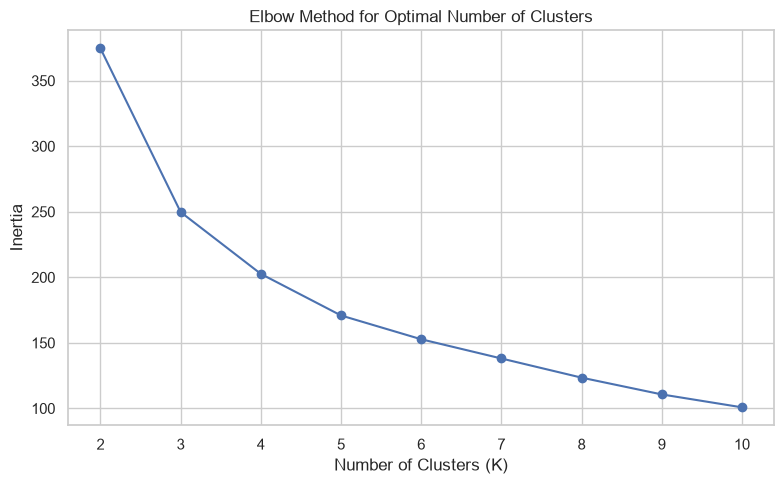

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()

## K-Means Clustering

K-Means clustering is used to divide customers into distinct groups based on their Recency, Frequency, and Monetary behaviour.

The number of clusters is selected using the Elbow Method.

Each customer will be assigned to one cluster based on the similarity of their standardized RFM characteristics.

In [63]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
CUST1001,220.0,6,37363.10,1
CUST1002,257.0,3,51965.75,1
CUST1003,389.0,4,12905.90,2
CUST1004,118.0,5,33686.15,1
CUST1005,56.0,7,18808.85,1


In [64]:
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [65]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    56
1    79
2    30
3    34
Name: count, dtype: int64

In [66]:
optimal_k = 4

## Cluster Visualization: Recency vs Frequency

This scatter plot visualizes the customer clusters based on Recency and Frequency.

The plot helps identify how recently customers purchased and how frequently they make purchases, and whether these behaviours differ across the identified customer segments.

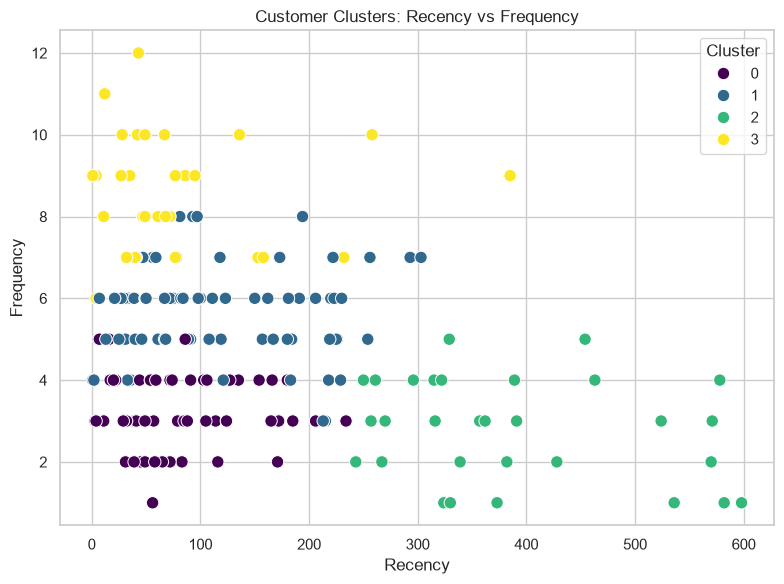

In [67]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Clusters: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

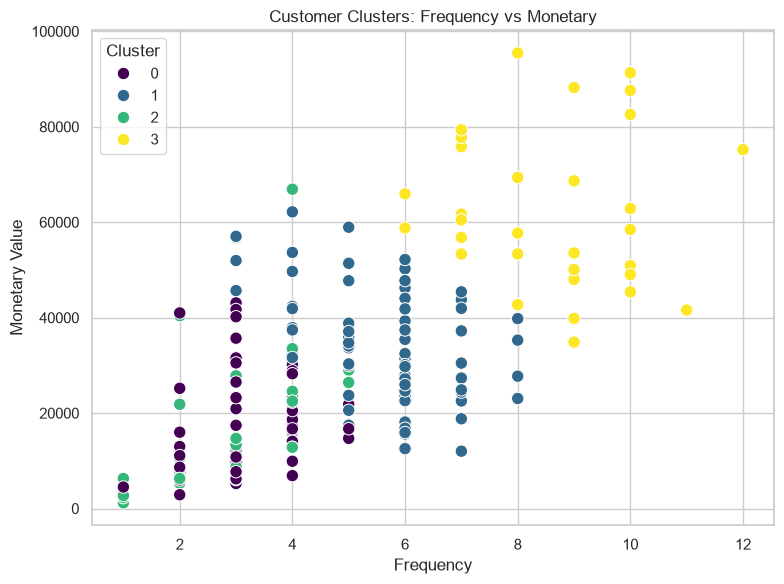

In [68]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Clusters: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

### Observation

The scatter plots show the distribution of customers across the identified K-Means clusters.

The Recency versus Frequency plot highlights differences in customer activity and purchasing frequency, while the Frequency versus Monetary plot shows differences in purchasing frequency and total spending.

The separation between clusters indicates that customers exhibit different purchasing behaviours. These differences can be used to develop targeted strategies for each customer segment.

## Cluster Profiling

Cluster profiling is used to understand the characteristics of each customer segment.

The mean Recency, Frequency, and Monetary values are calculated for each cluster. These averages help identify differences in customer purchasing behaviour and provide a basis for assigning meaningful descriptions to the customer segments.

In [70]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,78.767857,3.250000,19445.515179
1,112.341772,5.594937,33852.070886
2,389.233333,2.800000,17325.973333
3,79.058824,8.558824,62824.514706


In [71]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


## Customer Count by Cluster

The number of customers in each cluster is calculated to understand the size of each customer segment.

In [72]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    56
1    79
2    30
3    34
Name: count, dtype: int64

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The cluster profiling shows that the customer groups have different Recency, Frequency, and Monetary characteristics.

The customer-count chart shows the relative size of each segment. Some clusters contain a larger proportion of customers, while other clusters represent smaller and potentially more specialised customer groups.

The differences in RFM characteristics can be used to develop specific marketing strategies for each customer segment.

In [74]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


## Customer Segment Interpretation

The clusters are interpreted based on their average Recency, Frequency, and Monetary values.

Customers with low Recency, high Frequency, and high Monetary values can be considered highly valuable and active customers.

Customers with high Recency, low Frequency, and low Monetary values show lower engagement and spending.

The remaining clusters represent intermediate customer behaviours and require different levels of engagement and marketing attention.

## Marketing Recommendations by Customer Segment

### High-Value Active Customers

Customers with recent purchases, high purchase frequency, and high spending should be retained through loyalty programmes, exclusive offers, early access to new products, and personalised rewards.

### Regular Customers

Customers with moderate purchasing frequency and spending can be encouraged to purchase more frequently through personalised recommendations, bundle offers, and targeted promotions.

### Low-Engagement Customers

Customers with high Recency and relatively low Frequency or Monetary values can be targeted with re-engagement campaigns, personalised discounts, and reminders about relevant products.

### High-Spending but Less-Recent Customers

Customers who have previously generated high monetary value but have not purchased recently can be targeted with personalised win-back campaigns and special offers designed to encourage another purchase.

# Conclusion

The customer segmentation analysis used Recency, Frequency, and Monetary values to understand differences in customer purchasing behaviour.

The RFM features were standardised using StandardScaler before applying K-Means clustering. The Elbow Method was used to identify a suitable number of customer segments.

The resulting clusters revealed different customer behaviours based on purchase recency, purchase frequency, and total spending.

These segments provide a useful foundation for targeted marketing strategies. High-value customers can be prioritised for retention and loyalty initiatives, while less-engaged customers can be targeted through personalised re-engagement campaigns.

Overall, customer segmentation can help the business allocate marketing resources more effectively and develop strategies that are appropriate for different customer groups.

In [75]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


In [76]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


## Customer Segment Profiles

The customer clusters were interpreted based on their average Recency, Frequency, and Monetary values.

Each segment represents a different type of customer behaviour. The segment profiles can be used to develop targeted marketing strategies that match the purchasing behaviour of each group.

### Observation

The cluster profile highlights clear differences in purchasing behaviour between the customer segments.

The average Recency, Frequency, and Monetary values provide a basis for identifying highly active customers, regular customers, and less-engaged or at-risk customers.

The Customer_Count column also shows the relative size of each segment, which can help the business prioritise its marketing efforts.

In [77]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,78.767857,3.250000,19445.515179
1,112.341772,5.594937,33852.070886
2,389.233333,2.800000,17325.973333
3,79.058824,8.558824,62824.514706


In [78]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


## Customer Segment Interpretation and Marketing Actions

### Cluster 0
**Segment:** [Give the appropriate name based on the RFM values]

**Characteristics:**  
Describe the cluster using its Recency, Frequency, and Monetary values.

**Marketing Action:**  
Recommend a suitable marketing strategy for this customer segment.

### Cluster 1
**Segment:** [Give the appropriate name based on the RFM values]

**Characteristics:**  
Describe the cluster using its Recency, Frequency, and Monetary values.

**Marketing Action:**  
Recommend a suitable marketing strategy for this customer segment.

### Cluster 2
**Segment:** [Give the appropriate name based on the RFM values]

**Characteristics:**  
Describe the cluster using its Recency, Frequency, and Monetary values.

**Marketing Action:**  
Recommend a suitable marketing strategy for this customer segment.

### Cluster 3
**Segment:** [Give the appropriate name based on the RFM values]

**Characteristics:**  
Describe the cluster using its Recency, Frequency, and Monetary values.

**Marketing Action:**  
Recommend a suitable marketing strategy for this customer segment.

In [79]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51


# Conclusion

The customer segmentation analysis was performed using Recency, Frequency, and Monetary (RFM) features to understand differences in customer purchasing behaviour.

The dataset was cleaned and prepared before calculating the RFM metrics. The RFM features were then standardised using StandardScaler so that differences in scale would not disproportionately affect the clustering process.

The Elbow Method was used to determine a suitable number of clusters, and K-Means clustering was applied to group customers according to their purchasing behaviour.

The resulting customer segments showed differences in purchase recency, purchase frequency, and total spending. These differences provide useful information for developing targeted marketing strategies.

High-value and active customers can be prioritised for loyalty and retention campaigns, while less-engaged customers can be targeted with personalised re-engagement offers. Regular customers can be encouraged to increase their purchase frequency through personalised recommendations and promotions.

Overall, customer segmentation provides the business with a data-driven approach to understanding its customers and allocating marketing resources more effectively.

In [80]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
CUST1001,220.0,6,37363.10,1
CUST1002,257.0,3,51965.75,1
CUST1003,389.0,4,12905.90,2
CUST1004,118.0,5,33686.15,1
CUST1005,56.0,7,18808.85,1


In [81]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,78.77,3.25,19445.52
1,112.34,5.59,33852.07
2,389.23,2.80,17325.97
3,79.06,8.56,62824.51
